In [2]:
import subprocess
import os
import ssl
import matplotlib.pyplot as plt
import sys

ssl._create_default_https_context = ssl._create_unverified_context
sys.path.append(os.path.abspath("../..")) 

def get_repo_root():
    """Finds the absolute root directory of the current git repository (traversibility)."""
    try:
        root = subprocess.check_output(
            ["git", "rev-parse", "--show-toplevel"], 
            stderr=subprocess.STDOUT
        ).decode("utf-8").strip()
        return root
    except (subprocess.CalledProcessError, FileNotFoundError):
        raise RuntimeError("Could not determine repository root. Ensure you are inside the git repository.")

repo_root = get_repo_root()
id3100_dir = os.path.abspath(os.path.join(repo_root, ".."))

# Config file: repo_root/scripts/config/data_config.yaml
config_path = os.path.join(repo_root, "scripts/config/data_config.yaml")

In [3]:
DEPTH = os.path.join(id3100_dir, "ETH - Polyterasse/zed2i_depth_image")
RGB = os.path.join(id3100_dir, "ETH - Polyterasse/zed2i_right_images") 

fx, fy, cx, cy = 1052.19970703125, 1052.19970703125, 956.3457641601562, 553.95703125
depth_scale = 1000.0   # mm -> meters
depth_trunc = 30.0
frame_delay = 0.05

In [4]:
import yaml

with open(config_path, "r") as f:
    config = yaml.safe_load(f)


folder_name = config.get("folder") 

In [13]:
import numpy as np


def add_bev_normals(bev_map, cell_size=0.05, min_count=1):
    """
    Input:
        bev_map: (C, H, W)

        Channels:
            0: z_min
            1: z_max
            2: z_mean
            3: z_std
            4: counts
            5: occupied
            6: R
            7: G
            8: B

    Output:
        (C+3, H, W)

        Added:
            C+0: nx
            C+1: ny
            C+2: nz
    """

    z_mean = bev_map[2].astype(np.float32)
    counts = bev_map[4]
    occupied = bev_map[5].astype(bool)

    H, W = z_mean.shape

    # Cells containing enough points
    valid = occupied & (counts >= min_count)

    # ---------------------------------------------------------
    # Gradients
    # ---------------------------------------------------------

    dz_dx = np.zeros((H, W), dtype=np.float32)
    dz_dy = np.zeros((H, W), dtype=np.float32)

    # Central difference
    dz_dx[:, 1:-1] = (
        z_mean[:, 2:] - z_mean[:, :-2]
    ) / (2.0 * cell_size)

    dz_dy[1:-1, :] = (
        z_mean[2:, :] - z_mean[:-2, :]
    ) / (2.0 * cell_size)

    # ---------------------------------------------------------
    # Check that neighboring cells are valid
    # ---------------------------------------------------------

    valid_x = (
        valid[:, 1:-1]
        & valid[:, :-2]
        & valid[:, 2:]
    )
    # shape: (H, W-2)

    valid_y = (
        valid[1:-1, :]
        & valid[:-2, :]
        & valid[2:, :]
    )
    # shape: (H-2, W)

    normal_valid = np.zeros((H, W), dtype=bool)

    # Interior cells: (H-2, W-2)
    normal_valid[1:-1, 1:-1] = (
        valid_x[1:-1, :]
        & valid_y[:, 1:-1]
    )

    # ---------------------------------------------------------
    # Surface normal
    # ---------------------------------------------------------

    nx = -dz_dx
    ny = -dz_dy
    nz = np.ones((H, W), dtype=np.float32)

    norm = np.sqrt(
        nx**2 +
        ny**2 +
        nz**2
    )

    nx /= norm + 1e-8
    ny /= norm + 1e-8
    nz /= norm + 1e-8

    # ---------------------------------------------------------
    # Stack normals
    # ---------------------------------------------------------

    normals = np.stack(
        [nx, ny, nz],
        axis=0
    )  # (3, H, W)

    # Invalid normals -> NaN
    normals[:, ~normal_valid] = np.nan

    # ---------------------------------------------------------
    # Append to BEV
    # ---------------------------------------------------------

    bev_map_with_normals = np.concatenate(
        [bev_map, normals],
        axis=0
    )

    return bev_map_with_normals

In [14]:
import torch
def generate_bev_grid(
    points: np.ndarray,
    heights: np.ndarray,
    cell_size: float = 0.05,
    x_range: tuple = (0.0, 10.0),
    y_range: tuple = (-5.0, 5.0),
    colors: np.ndarray = None,
    normals: np.ndarray = None,
    feats = None
) -> np.ndarray:

    x_min, x_max = x_range
    y_min, y_max = y_range

    # Calculate grid dimensions
    H = int(np.round((x_max - x_min) / cell_size))  # Forward cells (rows)
    W = int(np.round((y_max - y_min) / cell_size))  # Lateral cells (cols)
    num_cells = H * W

    # Filter points within bounds
    x, y = points[:, 0], points[:, 1]
    valid_mask = (
        (x >= x_min) & (x < x_max) & (y >= y_min) & (y < y_max) & ~np.isnan(heights)
    )

    x_valid = x[valid_mask]
    y_valid = y[valid_mask]
    z_valid = heights[valid_mask]

    # Map coordinates to 2D grid cell indices
    row_idx = np.floor((x_valid - x_min) / cell_size).astype(np.int64)
    col_idx = np.floor((y_valid - y_min) / cell_size).astype(np.int64)

    # row_idx = np.clip(row_idx, 0, H - 1)
    # col_idx = np.clip(col_idx, 0, W - 1)

    row_idx = np.floor((x_max - x_valid) / cell_size).astype(np.int64)

    # Column index: y_min (left side) -> Col 0 (left of image)
    #               y_max (right side) -> Col W - 1 (right of image)
    col_idx = np.floor((y_valid - y_min) / cell_size).astype(np.int64)

    row_idx = np.clip(row_idx, 0, H - 1)
    col_idx = np.clip(col_idx, 0, W - 1)
    

    flat_idx = row_idx * W + col_idx

    # Initialize cell statistics
    counts = np.bincount(flat_idx, minlength=num_cells)
    occupied = counts > 0

    z_min = np.full(num_cells, np.nan)
    z_max = np.full(num_cells, np.nan)
    z_mean = np.full(num_cells, np.nan)
    z_std = np.full(num_cells, np.nan)

    # Vectorized accumulation for height statistics
    z_sum = np.bincount(flat_idx, weights=z_valid, minlength=num_cells)
    z_sq_sum = np.bincount(flat_idx, weights=z_valid**2, minlength=num_cells)

    z_min_tmp = np.full(num_cells, np.inf)
    z_max_tmp = np.full(num_cells, -np.inf)
    np.minimum.at(z_min_tmp, flat_idx, z_valid)
    np.maximum.at(z_max_tmp, flat_idx, z_valid)

    # Compute stats for occupied cells
    z_mean[occupied] = z_sum[occupied] / counts[occupied]
    z_var = (z_sq_sum[occupied] / counts[occupied]) - (z_mean[occupied] ** 2)
    z_std[occupied] = np.sqrt(np.maximum(z_var, 0.0))
    z_min[occupied] = z_min_tmp[occupied]
    z_max[occupied] = z_max_tmp[occupied]

    channels = [
        z_min.reshape(H, W),
        z_max.reshape(H, W),
        z_mean.reshape(H, W),
        z_std.reshape(H, W),
        counts.astype(np.float32).reshape(H, W),
        occupied.astype(np.float32).reshape(H, W),
    ]

    # Optional Channel Aggregations (RGB / Surface Normals)
    if colors is not None:
        colors_valid = colors[valid_mask]
        for c in range(colors_valid.shape[1]):
            c_sum = np.bincount(
                flat_idx, weights=colors_valid[:, c], minlength=num_cells
            )
            c_mean = np.full(num_cells, np.nan)
            c_mean[occupied] = c_sum[occupied] / counts[occupied]
            channels.append(c_mean.reshape(H, W))

    if normals is not None:
        normals_valid = normals[valid_mask]
        for n in range(normals_valid.shape[1]):
            n_sum = np.bincount(
                flat_idx, weights=normals_valid[:, n], minlength=num_cells
            )
            n_mean = np.full(num_cells, np.nan)
            n_mean[occupied] = n_sum[occupied] / counts[occupied]
            channels.append(n_mean.reshape(H, W))

    if feats is not None:
        f_valid = torch.from_numpy(feats[valid_mask]).float()
        C = f_valid.shape[1]
        bev_f = torch.zeros(num_cells, C)
        bev_f.index_add_(0, torch.from_numpy(flat_idx), f_valid)
        bev_f = bev_f / torch.from_numpy(counts).float().clamp(min=1)[:, None]
        # empty cells stay 0; the existing `occupied` channel is the flag
        channels.extend(list(bev_f.T.reshape(C, H, W).numpy()))

    return np.stack(channels, axis=0)

In [15]:
import open3d as o3d

def generate_bev_from_o3d(
    pcd: o3d.geometry.PointCloud, x_range, y_range, feats=None
) -> np.ndarray:
    pts_3d = np.asarray(pcd.points)
    colors = np.asarray(pcd.colors) if pcd.has_colors() else None
    normals = np.asarray(pcd.normals) if pcd.has_normals() else None

    # Open3D Camera Coordinates:
    # forward_dist = Z (pts_3d[:, 2])
    # lateral_dist = X (pts_3d[:, 0])
    # height       = -Y (pts_3d[:, 1], inverted because +Y points down in camera frame)

    bev_points = np.column_stack((pts_3d[:, 2], pts_3d[:, 0]))  # Forward (Z), Lateral (X)
    heights = pts_3d[:, 1]  # Invert Y so up is positive

    return generate_bev_grid(
        points=bev_points,
        heights=heights,
        x_range=x_range,
        y_range=y_range,
        colors=colors,
        normals=normals,
        feats=None
    )

In [29]:
from utils.BEV_helper_functions import fit_ground_plane, build_pcd, ranges

stem = '001000'

depth_file_path = os.path.join(DEPTH, stem+".png")
rgb_file_path = os.path.join(RGB, stem+".jpeg")

pcd = build_pcd(rgb_file_path,depth_file_path)
X_RANGE, Y_RANGE = ranges()
bev = generate_bev_from_o3d(pcd, X_RANGE, Y_RANGE, feats=None)
bev = add_bev_normals(bev)


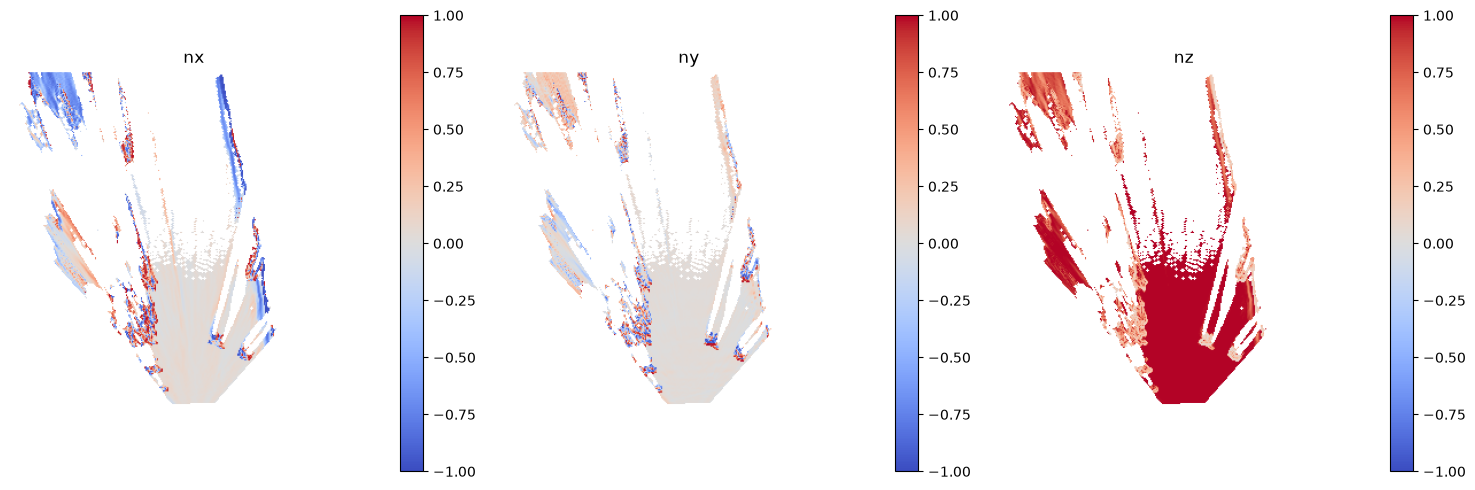

In [30]:
import matplotlib.pyplot as plt

nx = bev[9]
ny = bev[10]
nz = bev[11]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, normal, title in zip(
    axes,
    [nx, ny, nz],
    ["nx", "ny", "nz"]
):
    im = ax.imshow(normal, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

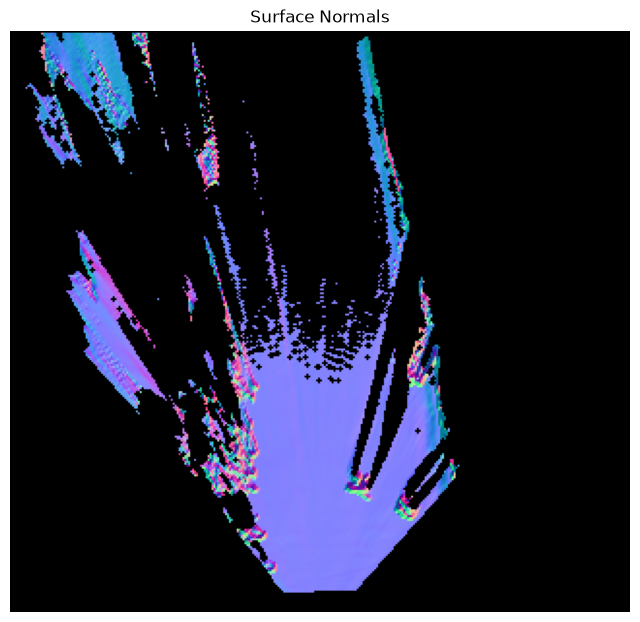

In [31]:
normal_rgb = np.stack(
    [
        (nx + 1) / 2,
        (ny + 1) / 2,
        (nz + 1) / 2,
    ],
    axis=-1
)

# Hide invalid cells
normal_rgb[np.isnan(normal_rgb).any(axis=-1)] = 0

plt.figure(figsize=(8, 8))
plt.imshow(normal_rgb)
plt.title("Surface Normals")
plt.axis("off")
plt.show()